# Analyse synchrone Winter 2019 : comportement + environnement + IceTag

**Objectif** : exploiter le jeu `Winter 2019` où les observations comportementales, les variables environnementales et les pas IceTag sont présents **dans la même table**.

Ce notebook sert à :
- vérifier la structure du corpus synchrone ;
- construire des **scores comportementaux agrégés** à partir des colonnes `Scan_*` ;
- comparer ces scores aux mesures `IceTag` ;
- documenter des **facteurs de contexte** utiles pour le projet McGill et pour la lecture prudente de ton projet personnel.

**Source principale** :
- `/Users/alioubarry/PROJECT/mcgill_iot_cattle/Données completes/Données accelerometres/Winter 2019/cow_scan_long-format_7.12.19.xlsx`
- feuille : `all scans FINAL`


## 1. Imports et chemins

In [3]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.style.use('default')
pd.set_option('display.max_columns', 200)
pd.set_option('display.width', 200)

PROJECT_ROOT = Path('/Users/alioubarry/PROJECT')
MCGILL_ROOT = PROJECT_ROOT / 'mcgill_iot_cattle'
WINTER_XLSX = MCGILL_ROOT / 'Données completes' / 'Données accelerometres' / 'Winter 2019' / 'cow_scan_long-format_7.12.19.xlsx'
REPORTS_DIR = MCGILL_ROOT / 'reports'
REPORTS_DIR.mkdir(parents=True, exist_ok=True)

WINTER_XLSX

PosixPath('/Users/alioubarry/PROJECT/mcgill_iot_cattle/Données completes/Données accelerometres/Winter 2019/cow_scan_long-format_7.12.19.xlsx')

## 2. Charger la table synchrone Winter 2019

In [6]:
df = pd.read_excel(WINTER_XLSX, sheet_name='all scans FINAL')

print('shape:', df.shape)
print('columns:', len(df.columns))
df.head()

shape: (42, 43)
columns: 43


,Date,Cow_ID,Week,Treatment_hour,Treatment_pad_size(m2),Paddock_number,Temp_7:15am_(C),Wind_speed_7:15am_(km/h),Windchill_index_7:15am,Weather_conditions,Paddock_surface_conditions,Gov_CAN_Temp_10am_(C),Gov_CAN_wind_speed_10am_(km/h),Gov_CAN_rel_humidity_10am_(%),Gov_CAN_Windchill_10am,Scan_SI,Scan_SR,Scan_SA,Scan_SW,Scan_SWR,Scan_PMH,Scan_SP,Scan_SN,Scan_W,Scan_EXI,Scan_EXW,Scan_SG,Scan_AG,Scan_ES,Scan_EW,Scan_KW,Scan_LD,Scan_EG,Scan_OT,Percentage_active,Scan_D_T,Scan_D_B,Scan_D_F,Distance_index_per_treatment_hour,Icetag_steps_per_treatment_hour1,Icetag_steps_per_treatment_hour2,Icetag_steps_2hours_total,Comments
0,2019-02-14,2056,1.0,2,80,8,-6.0,12.0,-11.0,light snow,snow,-7.3,25,68,-15.0,9,18,0,0,0,0,1,0,2,0,0,0,0,0,0,0,0,0,0,NaN,2,25,3,0.516667,256,229.0,485.0,2 hour cows done technically by 12:40 but stay...
1,2019-02-15,8510,1.2,1,40,14,-2.4,8.4,-6.0,snow,snow,2.0,18,71,NaN,0,14,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,NaN,4,11,0,0.366667,73,NaN,NaN,NaN
2,2019-02-15,3437,1.2,1,80,16,-2.4,8.4,-6.0,snow,snow,2.0,18,71,NaN,5,7,0,0,0,3,0,0,0,0,0,0,0,0,0,0,0,0,0,NaN,4,10,1,0.400000,217,NaN,NaN,NaN
3,2019-02-15,8508,1.2,1,20,12,-2.4,8.4,-6.0,snow,snow,2.0,18,71,NaN,1,6,0,0,8,0,0,0,0,0,0,0,0,0,0,0,0,0,0,NaN,3,12,0,0.400000,28,NaN,NaN,NaN
4,2019-02-15,2081,1.2,2,60,2,-2.4,8.4,-6.0,snow,snow,2.0,18,71,NaN,3,12,0,5,6,1,1,0,0,1,1,0,0,0,0,0,0,0,0,NaN,8,21,1,0.383333,72,63.0,135.0,NaN


## 3. Audit rapide du corpus

In [9]:
df['Date'] = pd.to_datetime(df['Date'])

summary = {
    'n_rows': len(df),
    'n_cows': df['Cow_ID'].nunique(),
    'date_min': df['Date'].min(),
    'date_max': df['Date'].max(),
    'weeks': df['Week'].value_counts().sort_index().to_dict(),
    'treatment_hours': df['Treatment_hour'].value_counts().sort_index().to_dict(),
    'pad_sizes': df['Treatment_pad_size(m2)'].value_counts().sort_index().to_dict(),
    'weather': df['Weather_conditions'].value_counts().to_dict(),
    'surface': df['Paddock_surface_conditions'].value_counts().to_dict(),
}
summary

{'n_rows': 42,
 'n_cows': 8,
 'date_min': Timestamp('2019-02-14 00:00:00'),
 'date_max': Timestamp('2019-04-05 00:00:00'),
 'weeks': {1.0: 1, 1.2: 6, 2.0: 6, 4.0: 6, 5.0: 8, 7.2: 8, 8.0: 7},
 'treatment_hours': {1: 21, 2: 21},
 'pad_sizes': {20: 11, 40: 10, 60: 11, 80: 10},
 'weather': {'clear': 27, 'rain': 8, 'snow': 6, 'light snow': 1},
 'surface': {'snow': 19, 'wood chips': 15, 'wet': 8}}

In [11]:
df.groupby('Cow_ID').agg(
    n_obs=('Cow_ID', 'size'),
    first_date=('Date', 'min'),
    last_date=('Date', 'max'),
    mean_steps_hour1=('Icetag_steps_per_treatment_hour1', 'mean'),
    mean_steps_2h_total=('Icetag_steps_2hours_total', 'mean'),
).sort_index()

,n_obs,first_date,last_date,mean_steps_hour1,mean_steps_2h_total
Cow_ID,,,,,
2056,6,2019-02-14,2019-04-05,108.666667,282.500000
2081,6,2019-02-15,2019-04-05,83.500000,153.500000
3437,5,2019-02-15,2019-03-29,146.800000,291.000000
3443,6,2019-02-15,2019-04-05,101.166667,246.500000
5246,3,2019-03-15,2019-04-05,42.333333,99.333333
5250,5,2019-02-15,2019-04-05,106.600000,390.000000
8508,5,2019-02-15,2019-04-05,76.200000,148.000000
8510,6,2019-02-15,2019-04-05,79.166667,197.500000


## 4. Construire les scores comportementaux

Le fichier `references` du classeur associe les codes `Scan_*` à des catégories :
- **Active mobile** : comportement impliquant des pas / du mouvement ;
- **Active immobile** : activité sans déplacement net ;
- **Rumination** ;
- **Immobile**.

On transforme cela en variables plus faciles à comparer aux pas IceTag.


In [14]:
SCAN_CATEGORY_MAP = {
    'Scan_SI': 'immobile',
    'Scan_SR': 'rumination',
    'Scan_SA': 'immobile',
    'Scan_SW': 'immobile',
    'Scan_SWR': 'rumination',
    'Scan_PMH': 'active_mobile',
    'Scan_SP': 'active_immobile',
    'Scan_SN': 'active_mobile',
    'Scan_W': 'active_mobile',
    'Scan_EXI': 'active_immobile',
    'Scan_EXW': 'active_mobile',
    'Scan_SG': 'active_immobile',
    'Scan_AG': 'active_immobile',
    'Scan_ES': 'active_immobile',
    'Scan_EW': 'active_immobile',
    'Scan_KW': 'active_immobile',
    'Scan_LD': 'immobile',
    'Scan_EG': 'active_immobile',
    'Scan_OT': 'other',
}

scan_cols = list(SCAN_CATEGORY_MAP.keys())
category_weights = {
    'active_mobile': 1.0,
    'active_immobile': 0.5,
    'rumination': 0.25,
    'immobile': 0.0,
    'other': 0.0,
}

for cat in sorted(set(SCAN_CATEGORY_MAP.values())):
    cols = [c for c, mapped in SCAN_CATEGORY_MAP.items() if mapped == cat]
    df[f'count_{cat}'] = df[cols].sum(axis=1)

category_cols = [f'count_{cat}' for cat in sorted(set(SCAN_CATEGORY_MAP.values()))]
df['total_scans'] = df[category_cols].sum(axis=1)

for cat in sorted(set(SCAN_CATEGORY_MAP.values())):
    df[f'pct_{cat}'] = np.where(
        df['total_scans'] > 0,
        df[f'count_{cat}'] / df['total_scans'],
        np.nan,
    )

weighted_sum = sum(df[f'count_{cat}'] * weight for cat, weight in category_weights.items())
df['behavior_activity_score'] = np.where(
    df['total_scans'] > 0,
    weighted_sum / df['total_scans'],
    np.nan,
)

cols_to_show = [
    'Date', 'Cow_ID', 'Treatment_hour', 'Treatment_pad_size(m2)',
    'count_active_mobile', 'count_active_immobile', 'count_rumination', 'count_immobile',
    'pct_active_mobile', 'pct_active_immobile', 'pct_rumination', 'pct_immobile',
    'behavior_activity_score'
]
df[cols_to_show].head(10)

,Date,Cow_ID,Treatment_hour,Treatment_pad_size(m2),count_active_mobile,count_active_immobile,count_rumination,count_immobile,pct_active_mobile,pct_active_immobile,pct_rumination,pct_immobile,behavior_activity_score
0,2019-02-14,2056,2,80,2,1,18,9,0.066667,0.033333,0.600000,0.300000,0.233333
1,2019-02-15,8510,1,40,1,0,14,0,0.066667,0.000000,0.933333,0.000000,0.300000
2,2019-02-15,3437,1,80,3,0,7,5,0.200000,0.000000,0.466667,0.333333,0.316667
3,2019-02-15,8508,1,20,0,0,14,1,0.000000,0.000000,0.933333,0.066667,0.233333
4,2019-02-15,2081,2,60,2,2,18,8,0.066667,0.066667,0.600000,0.266667,0.250000
5,2019-02-15,3443,2,40,0,1,23,6,0.000000,0.033333,0.766667,0.200000,0.208333
6,2019-02-15,5250,2,20,2,0,2,26,0.066667,0.000000,0.066667,0.866667,0.083333
7,2019-02-22,5250,1,60,0,2,5,8,0.000000,0.133333,0.333333,0.533333,0.150000
8,2019-02-22,3443,1,80,2,3,5,5,0.133333,0.200000,0.333333,0.333333,0.316667
9,2019-02-22,8510,1,20,0,1,8,6,0.000000,0.066667,0.533333,0.400000,0.166667


## 5. Construire les variables IceTag comparables

Comme certaines séances durent `1h` et d'autres `2h`, on crée :
- `icetag_steps_session_total` : total observé sur la session ;
- `icetag_steps_per_hour_norm` : version normalisée par heure pour comparer équitablement les sessions.


In [17]:
df['icetag_steps_session_total'] = np.where(
    df['Treatment_hour'] == 1,
    df['Icetag_steps_per_treatment_hour1'],
    df['Icetag_steps_2hours_total'],
)

df['icetag_steps_per_hour_norm'] = np.where(
    df['Treatment_hour'] == 1,
    df['Icetag_steps_per_treatment_hour1'],
    df['Icetag_steps_2hours_total'] / df['Treatment_hour'],
)

df[['Date', 'Cow_ID', 'Treatment_hour', 'Icetag_steps_per_treatment_hour1', 'Icetag_steps_per_treatment_hour2', 'Icetag_steps_2hours_total', 'icetag_steps_session_total', 'icetag_steps_per_hour_norm']].head(10)

,Date,Cow_ID,Treatment_hour,Icetag_steps_per_treatment_hour1,Icetag_steps_per_treatment_hour2,Icetag_steps_2hours_total,icetag_steps_session_total,icetag_steps_per_hour_norm
0,2019-02-14,2056,2,256,229.0,485.0,485.0,242.5
1,2019-02-15,8510,1,73,NaN,NaN,73.0,73.0
2,2019-02-15,3437,1,217,NaN,NaN,217.0,217.0
3,2019-02-15,8508,1,28,NaN,NaN,28.0,28.0
4,2019-02-15,2081,2,72,63.0,135.0,135.0,67.5
5,2019-02-15,3443,2,73,145.0,218.0,218.0,109.0
6,2019-02-15,5250,2,169,221.0,390.0,390.0,195.0
7,2019-02-22,5250,1,84,NaN,NaN,84.0,84.0
8,2019-02-22,3443,1,155,NaN,NaN,155.0,155.0
9,2019-02-22,8510,1,68,NaN,NaN,68.0,68.0


## 6. Corrélations comportement ↔ IceTag

In [20]:
corr_cols = [
    'icetag_steps_per_hour_norm',
    'icetag_steps_session_total',
    'count_active_mobile',
    'count_active_immobile',
    'count_rumination',
    'count_immobile',
    'pct_active_mobile',
    'pct_active_immobile',
    'pct_rumination',
    'pct_immobile',
    'behavior_activity_score',
    'Distance_index_per_treatment_hour',
    'Treatment_hour',
    'Treatment_pad_size(m2)',
    'Temp_7:15am_(C)',
    'Gov_CAN_Temp_10am_(C)',
    'Gov_CAN_rel_humidity_10am_(%)',
]

corr = df[corr_cols].corr(numeric_only=True)
step_corr = corr['icetag_steps_per_hour_norm'].sort_values(ascending=False)
step_corr.to_frame('corr_with_icetag_steps_per_hour_norm')

,corr_with_icetag_steps_per_hour_norm
icetag_steps_per_hour_norm,1.000000
icetag_steps_session_total,0.815015
count_active_mobile,0.428065
pct_active_mobile,0.400645
Treatment_pad_size(m2),0.297707
pct_immobile,0.283564
count_immobile,0.255862
behavior_activity_score,0.106841
Treatment_hour,0.102907
Gov_CAN_rel_humidity_10am_(%),0.005430


## 7. Résumés par vache et par contexte

In [23]:
by_cow = df.groupby('Cow_ID').agg(
    n_obs=('Cow_ID', 'size'),
    mean_steps_per_hour=('icetag_steps_per_hour_norm', 'mean'),
    mean_behavior_score=('behavior_activity_score', 'mean'),
    mean_pct_active_mobile=('pct_active_mobile', 'mean'),
    mean_pct_immobile=('pct_immobile', 'mean'),
    mean_distance_index=('Distance_index_per_treatment_hour', 'mean'),
).sort_values('mean_steps_per_hour', ascending=False)

by_cow

,n_obs,mean_steps_per_hour,mean_behavior_score,mean_pct_active_mobile,mean_pct_immobile,mean_distance_index
Cow_ID,,,,,,
3437,5,157.900000,0.298333,0.153333,0.333333,0.423333
2056,6,125.166667,0.211111,0.033333,0.361111,0.616667
5250,5,111.800000,0.163333,0.040000,0.506667,0.656667
3443,6,106.583333,0.252778,0.050000,0.227778,0.519444
8508,5,84.400000,0.291667,0.106667,0.213333,0.410000
8510,6,83.750000,0.244444,0.055556,0.233333,0.550000
2081,6,79.333333,0.258333,0.083333,0.316667,0.516667
5246,3,49.666667,0.205556,0.011111,0.311111,0.583333


In [25]:
by_context = df.groupby(['Treatment_hour', 'Treatment_pad_size(m2)', 'Weather_conditions']).agg(
    n_obs=('Cow_ID', 'size'),
    mean_steps_per_hour=('icetag_steps_per_hour_norm', 'mean'),
    mean_behavior_score=('behavior_activity_score', 'mean'),
    mean_pct_active_mobile=('pct_active_mobile', 'mean'),
    mean_pct_immobile=('pct_immobile', 'mean'),
).reset_index().sort_values(['Treatment_hour', 'Treatment_pad_size(m2)', 'Weather_conditions'])

by_context.head(20)

,Treatment_hour,Treatment_pad_size(m2),Weather_conditions,n_obs,mean_steps_per_hour,mean_behavior_score,mean_pct_active_mobile,mean_pct_immobile
0,1,20,clear,4,85.000,0.233333,0.050000,0.250000
1,1,20,rain,1,62.000,0.266667,0.000000,0.066667
2,1,20,snow,1,28.000,0.233333,0.000000,0.066667
3,1,40,clear,2,60.500,0.250000,0.033333,0.133333
4,1,40,rain,1,62.000,0.183333,0.066667,0.533333
5,1,40,snow,1,73.000,0.300000,0.066667,0.000000
6,1,60,clear,4,102.250,0.279167,0.083333,0.283333
7,1,60,rain,1,116.000,0.466667,0.333333,0.133333
8,1,80,clear,4,138.250,0.233333,0.083333,0.416667
9,1,80,rain,1,63.000,0.283333,0.066667,0.133333


## 8. Visualisations rapides

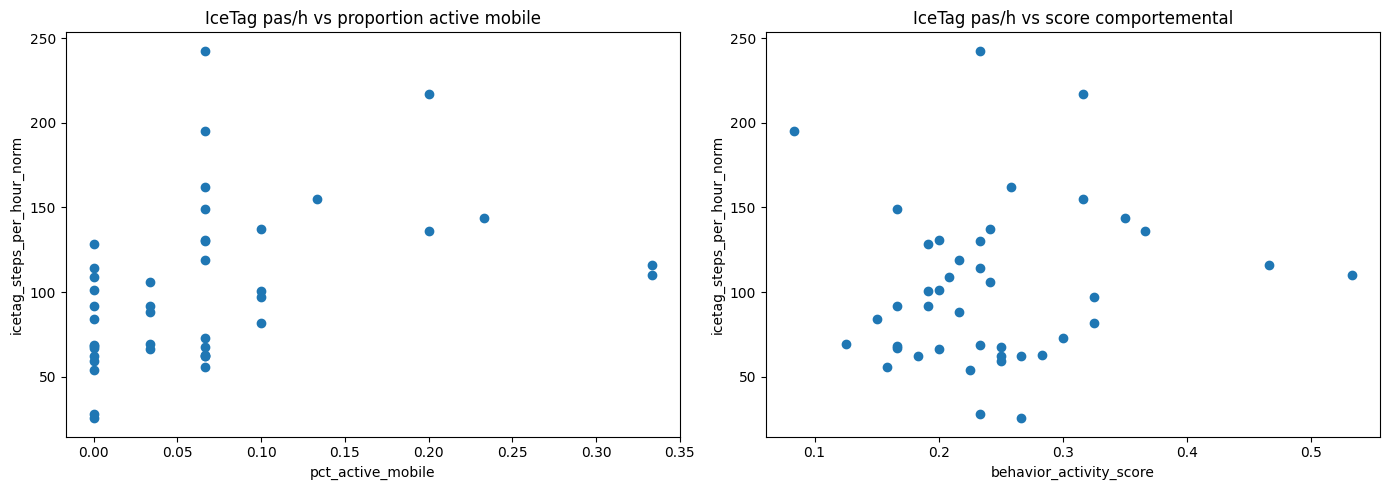

In [28]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].scatter(df['pct_active_mobile'], df['icetag_steps_per_hour_norm'])
axes[0].set_title('IceTag pas/h vs proportion active mobile')
axes[0].set_xlabel('pct_active_mobile')
axes[0].set_ylabel('icetag_steps_per_hour_norm')

axes[1].scatter(df['behavior_activity_score'], df['icetag_steps_per_hour_norm'])
axes[1].set_title('IceTag pas/h vs score comportemental')
axes[1].set_xlabel('behavior_activity_score')
axes[1].set_ylabel('icetag_steps_per_hour_norm')

plt.tight_layout()
plt.show()

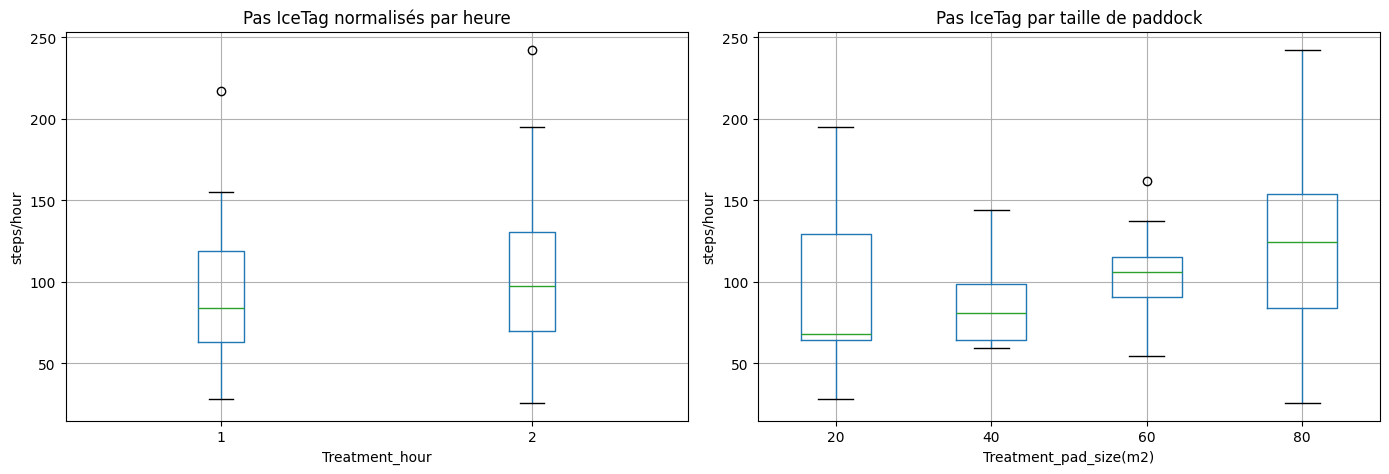

In [30]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

df.boxplot(column='icetag_steps_per_hour_norm', by='Treatment_hour', ax=axes[0])
axes[0].set_title('Pas IceTag normalisés par heure')
axes[0].set_xlabel('Treatment_hour')
axes[0].set_ylabel('steps/hour')

order = sorted(df['Treatment_pad_size(m2)'].dropna().unique())
df.boxplot(column='icetag_steps_per_hour_norm', by='Treatment_pad_size(m2)', ax=axes[1])
axes[1].set_title('Pas IceTag par taille de paddock')
axes[1].set_xlabel('Treatment_pad_size(m2)')
axes[1].set_ylabel('steps/hour')

plt.suptitle('')
plt.tight_layout()
plt.show()

## 9. Exports utiles

In [33]:
enriched_csv = REPORTS_DIR / 'winter2019_sync_enriched.csv'
by_cow_csv = REPORTS_DIR / 'winter2019_sync_by_cow.csv'
by_context_csv = REPORTS_DIR / 'winter2019_sync_by_context.csv'
corr_csv = REPORTS_DIR / 'winter2019_sync_correlations.csv'

df.to_csv(enriched_csv, index=False)
by_cow.to_csv(by_cow_csv)
by_context.to_csv(by_context_csv, index=False)
step_corr.to_csv(corr_csv, header=['corr_with_icetag_steps_per_hour_norm'])

print(enriched_csv)
print(by_cow_csv)
print(by_context_csv)
print(corr_csv)

/Users/alioubarry/PROJECT/mcgill_iot_cattle/reports/winter2019_sync_enriched.csv
/Users/alioubarry/PROJECT/mcgill_iot_cattle/reports/winter2019_sync_by_cow.csv
/Users/alioubarry/PROJECT/mcgill_iot_cattle/reports/winter2019_sync_by_context.csv
/Users/alioubarry/PROJECT/mcgill_iot_cattle/reports/winter2019_sync_correlations.csv


## 10. Lecture prudente pour ton projet personnel

Ce corpus Winter 2019 peut **aider** ton projet personnel, mais il faut rester exact sur ce qu'il prouve :

- **Oui** : il fournit une validation comportementale externe synchronisée.
  - On peut vérifier si les signaux locomoteurs captent bien plus d'activité observée.
- **Oui** : il permet d'étudier des **facteurs de confusion** environnementaux et contextuels.
- **Non** : ce n'est pas une validation clinique de boiterie, car il n'y a pas ici un label vétérinaire synchrone de boiterie attaché aux mêmes lignes.

La bonne utilisation est donc :
- projet McGill : corpus central pour l'analyse comportement + environnement + IceTag ;
- projet personnel : corpus secondaire utile pour discuter la généralisabilité comportementale et le rôle du contexte.
